In [24]:
import torch
from dynamics import distill_dynamics, get_initial_states

def u_func_template(t, steering_table, num_steps, dt):
    idx = (t / dt).long()
    idx = torch.clamp(idx, min=0, max=num_steps - 1)
    
    return steering_table[idx]

In [ ]:
from torchdiffeq import odeint
from matplotlib import pyplot as plt
torch.manual_seed(69)

num_dim = 32
NUM_TRAJECTORIES = 8
NUM_TRAJECTORIES_VAL = 3
T = 1000
CHUNK_LEN = 40
dt = 1.0
NUM_STEERING_JUMP = 10
STABILITY_THRESHOLD = 0.1
TOTAL_STEPS = int(T / dt) 
xmax = 1
xmin = 0
steps_per_jump = TOTAL_STEPS // NUM_STEERING_JUMP

steering_table = (torch.rand((NUM_STEERING_JUMP, NUM_TRAJECTORIES, 1))*9+1).repeat_interleave(steps_per_jump, dim=0)
steering_table_val = (torch.rand((NUM_STEERING_JUMP, NUM_TRAJECTORIES_VAL, 1))*9+1).repeat_interleave(steps_per_jump, dim=0)

u_func = lambda t: u_func_template(t, steering_table=steering_table, num_steps=TOTAL_STEPS, dt=dt)
u_func_val = lambda t: u_func_template(t, steering_table=steering_table_val, num_steps=TOTAL_STEPS, dt=dt)

y_0s = get_initial_states(steering_table)

y_0s_val = get_initial_states(steering_table_val)

print("Initial states calculated")

chunk_steps = int(CHUNK_LEN / dt)
num_chunks = int(T / CHUNK_LEN)
ts = torch.linspace(0, T, int(T/dt))

dynamics = torch.compile(lambda t, state: distill_dynamics(t, state, u_func=u_func))
dynamcis_val = torch.compile(lambda t, state: distill_dynamics(t, state, u_func=u_func_val))

trajectories = odeint(dynamics, y_0s, ts)
trajectories_val = odeint(dynamcis_val, y_0s_val, ts)

Initial states calculated


Train shape: torch.Size([1000, 8, 32])
Val shape: torch.Size([1000, 3, 32])


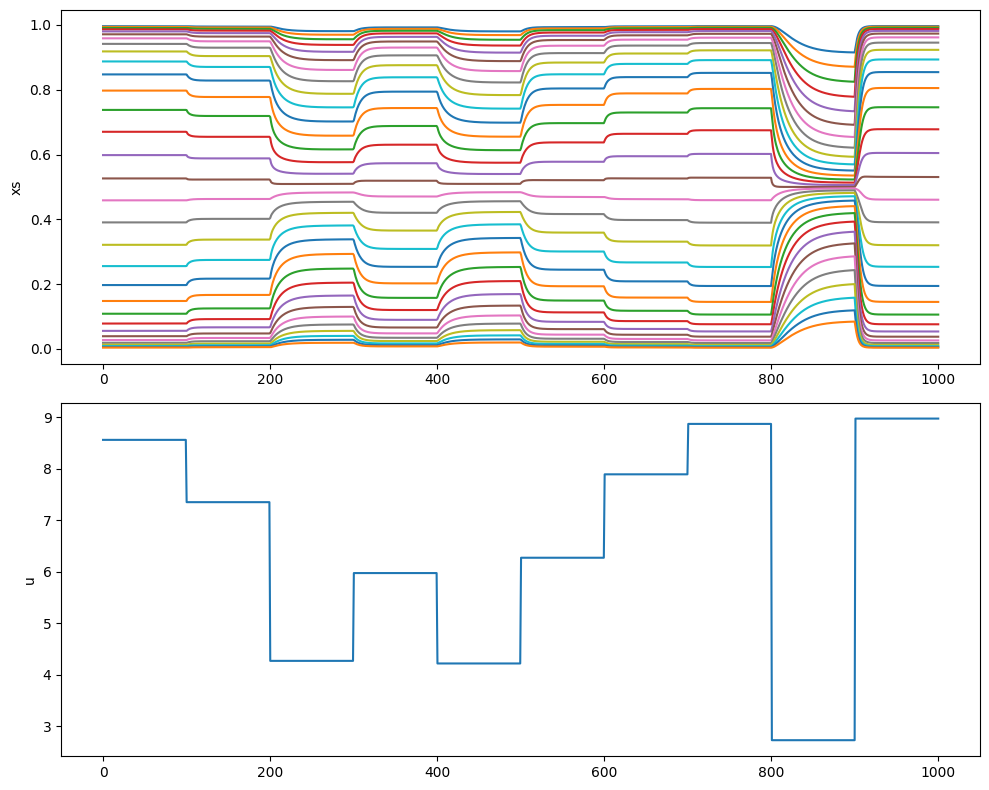

In [26]:
print("Train shape:", trajectories.shape)
print("Val shape:", trajectories_val.shape)

fig, axs = plt.subplots(2, figsize=(10, 8))


u_vals = steering_table[:, 0, 0]

for i in range(num_dim):
    axs[0].plot(ts, trajectories[:, 0, i].tolist())

axs[1].plot(ts, u_vals)

axs[0].set_ylabel("xs")
axs[1].set_ylabel("u")

plt.tight_layout()
plt.show()

In [27]:
import torch.nn as nn

class DynamicsModel(nn.Module):
    def __init__(self, state_dim=32, control_dim=1, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim + control_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, state_dim)
        )

    def forward(self, t, state, u_func):
        u_val = u_func(t)
        if u_val.dim() < state.dim():
            u_val = u_val.expand(*state.shape[:-1], -1)
        
        x = torch.cat([state, u_val], dim=-1)
        return self.net(x)

In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DynamicsModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

ts = ts.to(device)
trajectories = trajectories.to(device)
trajectories_val = trajectories_val.to(device)
y_0s_val = y_0s_val.to(device)
steering_table = steering_table.to(device)
steering_table_val = steering_table_val.to(device)

def nn_dynamics(t, state):
    return model(t, state, u_func)

def nn_dynamics_val(t, state):
    return model(t, state, u_func_val)

In [29]:
EPOCHS = 100
VAL_FREQ = 10

for epoch in range(EPOCHS):
    model.train()
    optimizer.zero_grad()
    epoch_loss = 0.0

    for i in range(num_chunks):
        start_idx = i * chunk_steps
        end_idx = start_idx + chunk_steps
        
        if end_idx > len(ts):
            break
            
        t_chunk = ts[start_idx:end_idx]
        y0_chunk = trajectories[start_idx]
        target_chunk = trajectories[start_idx:end_idx]

        pred_chunk = odeint(
            nn_dynamics, 
            y0_chunk, 
            t_chunk, 
            method='rk4', 
            options={'step_size': dt}
        )
        
        loss = criterion(pred_chunk, target_chunk)
        loss.backward()
        epoch_loss += loss.item()
        
        optimizer.step()
    
    if epoch % VAL_FREQ == 0 or epoch == EPOCHS - 1:
        model.eval()
        with torch.no_grad():
            val_loss = 0.0
            for i in range(num_chunks):
                start_idx = i * chunk_steps
                end_idx = start_idx + chunk_steps
                if end_idx > len(ts):
                    break
                
                t_chunk = ts[start_idx:end_idx]
                y0_chunk = trajectories_val[start_idx]
                target_chunk = trajectories_val[start_idx:end_idx]

                pred_chunk = odeint(
                    nn_dynamics_val, 
                    y0_chunk, 
                    t_chunk, 
                    method='rk4', 
                    options={'step_size': dt}
                )
                val_loss += criterion(pred_chunk, target_chunk).item()
                
        print(f"Epoch {epoch:03d} | Train Loss: {epoch_loss / num_chunks:.6f} | Val Loss: {val_loss / num_chunks:.6f}")

Epoch 000 | Train Loss: 8.042156 | Val Loss: 4.633869
Epoch 010 | Train Loss: 0.097889 | Val Loss: 0.086778
Epoch 020 | Train Loss: 0.039536 | Val Loss: 0.029728
Epoch 030 | Train Loss: 0.006351 | Val Loss: 0.006886
Epoch 040 | Train Loss: 0.011181 | Val Loss: 0.005299
Epoch 050 | Train Loss: 0.008147 | Val Loss: 0.003740
Epoch 060 | Train Loss: 0.008224 | Val Loss: 0.003761
Epoch 070 | Train Loss: 0.009053 | Val Loss: 0.003654
Epoch 080 | Train Loss: 0.018251 | Val Loss: 0.007781
Epoch 090 | Train Loss: 0.011542 | Val Loss: 0.005275
Epoch 099 | Train Loss: 0.018627 | Val Loss: 0.008120


In [30]:
print("Rozpoczynam fazę 2: L-BFGS...")

lbfgs_optimizer = torch.optim.LBFGS(
    model.parameters(), 
    max_iter=100, 
    tolerance_grad=1e-5, 
    tolerance_change=1e-9, 
    history_size=50,
    line_search_fn="strong_wolfe"
)

model.train()

LBFGS_STEPS = 5

for step in range(LBFGS_STEPS):
    def closure():
        lbfgs_optimizer.zero_grad()
        epoch_loss = 0.0
        
        for i in range(num_chunks):
            start_idx = i * chunk_steps
            end_idx = start_idx + chunk_steps
            
            if end_idx > len(ts):
                break
                
            t_chunk = ts[start_idx:end_idx]
            y0_chunk = trajectories[start_idx]
            target_chunk = trajectories[start_idx:end_idx]

            pred_chunk = odeint(
                nn_dynamics, 
                y0_chunk, 
                t_chunk, 
                method='rk4', 
                options={'step_size': dt}
            )
            
            loss = criterion(pred_chunk, target_chunk)
            loss.backward()
            epoch_loss += loss.item()
            
        return epoch_loss

    # Wywołanie optymalizatora
    lbfgs_optimizer.step(closure)
    
    # Obliczenie końcowego błędu po kroku dla wyświetlenia
    current_loss = closure() / num_chunks
    print(f"L-BFGS Step {step:02d} | Train Loss: {current_loss:.6f}")

Rozpoczynam fazę 2: L-BFGS...
L-BFGS Step 00 | Train Loss: 0.000233
L-BFGS Step 01 | Train Loss: 0.000084
L-BFGS Step 02 | Train Loss: 0.000045
L-BFGS Step 03 | Train Loss: 0.000030
L-BFGS Step 04 | Train Loss: 0.000021


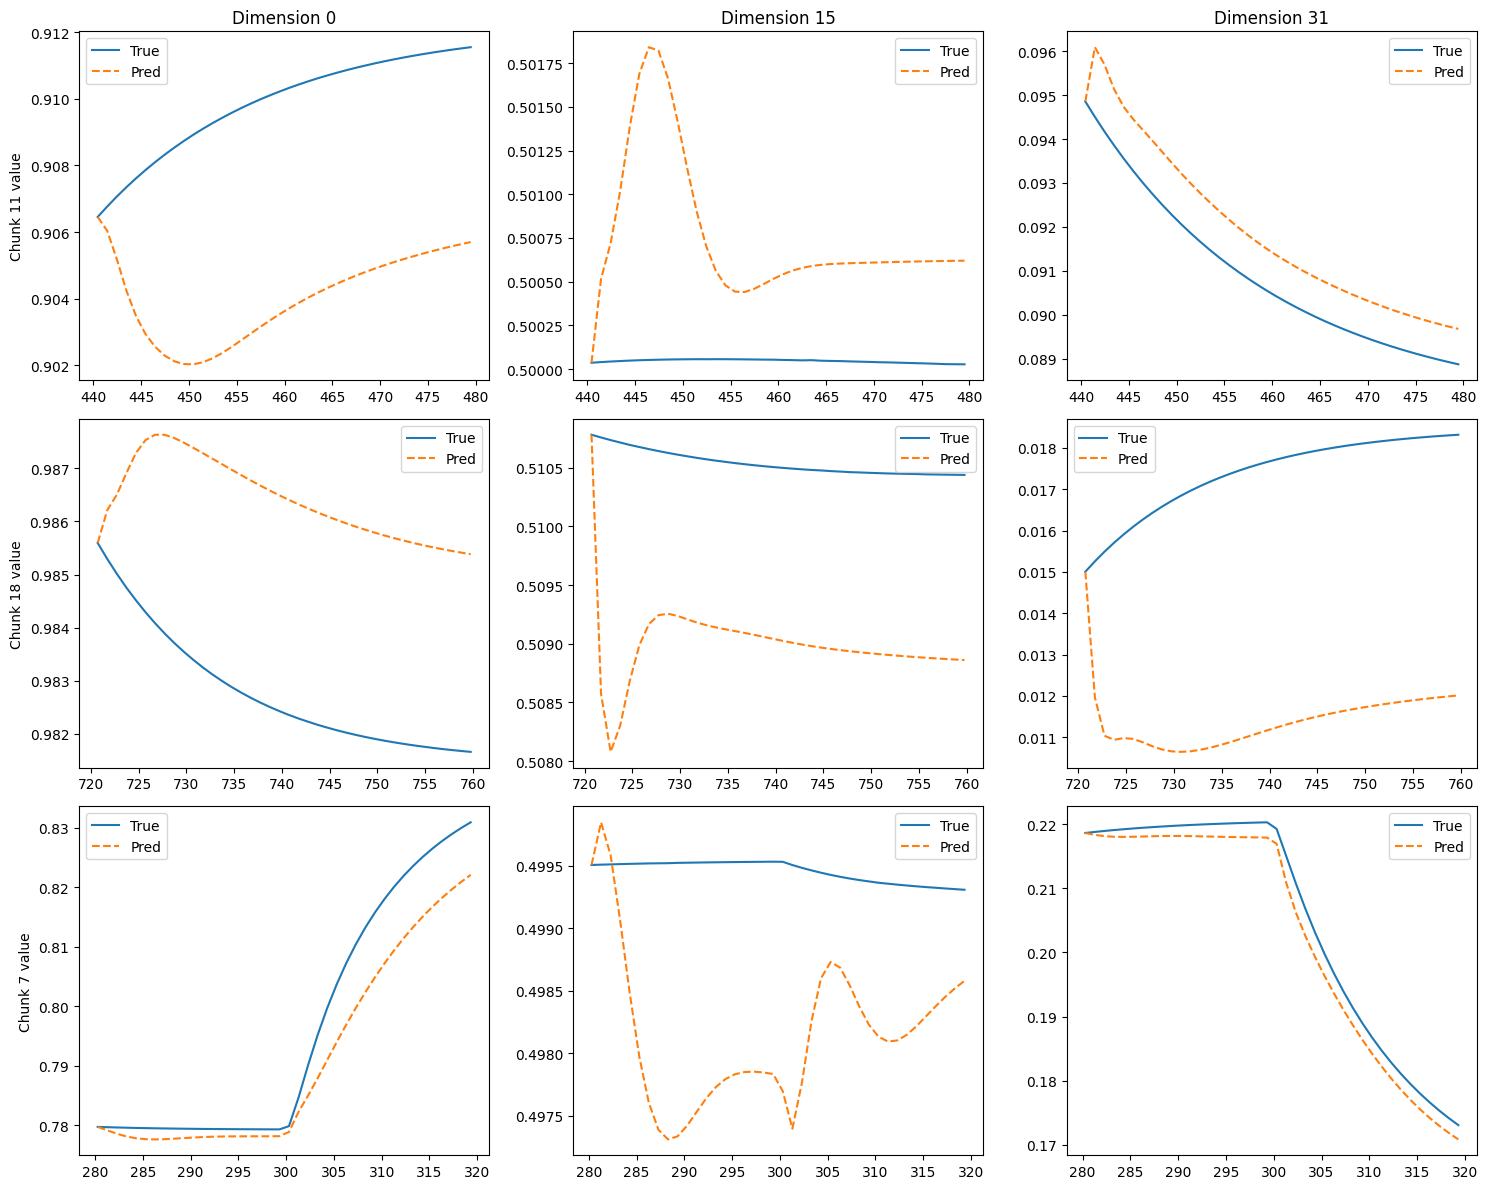

In [31]:
import random

model.eval()

num_chunks_to_plot = 3
random_chunks = random.sample(range(num_chunks), num_chunks_to_plot)
traj_idx = 0 
dims_to_plot = [0, 15, 31]

fig, axes = plt.subplots(num_chunks_to_plot, len(dims_to_plot), figsize=(15, 4 * num_chunks_to_plot))

with torch.no_grad():
    for i, chunk_idx in enumerate(random_chunks):
        start_idx = chunk_idx * chunk_steps
        end_idx = start_idx + chunk_steps
        
        if end_idx > len(ts):
            end_idx = len(ts)
            
        t_chunk = ts[start_idx:end_idx]
        y0_chunk = trajectories_val[start_idx]
        target_chunk = trajectories_val[start_idx:end_idx]
        
        pred_chunk = odeint(
            nn_dynamics_val, 
            y0_chunk, 
            t_chunk, 
            method='rk4', 
            options={'step_size': dt}
        )
        
        for j, d in enumerate(dims_to_plot):
            ax = axes[i, j] if num_chunks_to_plot > 1 else axes[j]
            
            ax.plot(t_chunk.cpu(), target_chunk[:, traj_idx, d].cpu(), label='True')
            ax.plot(t_chunk.cpu(), pred_chunk[:, traj_idx, d].cpu(), '--', label='Pred')
            
            if j == 0:
                ax.set_ylabel(f'Chunk {chunk_idx} value')
            if i == 0:
                ax.set_title(f'Dimension {d}')
            ax.legend()

plt.tight_layout()
plt.show()

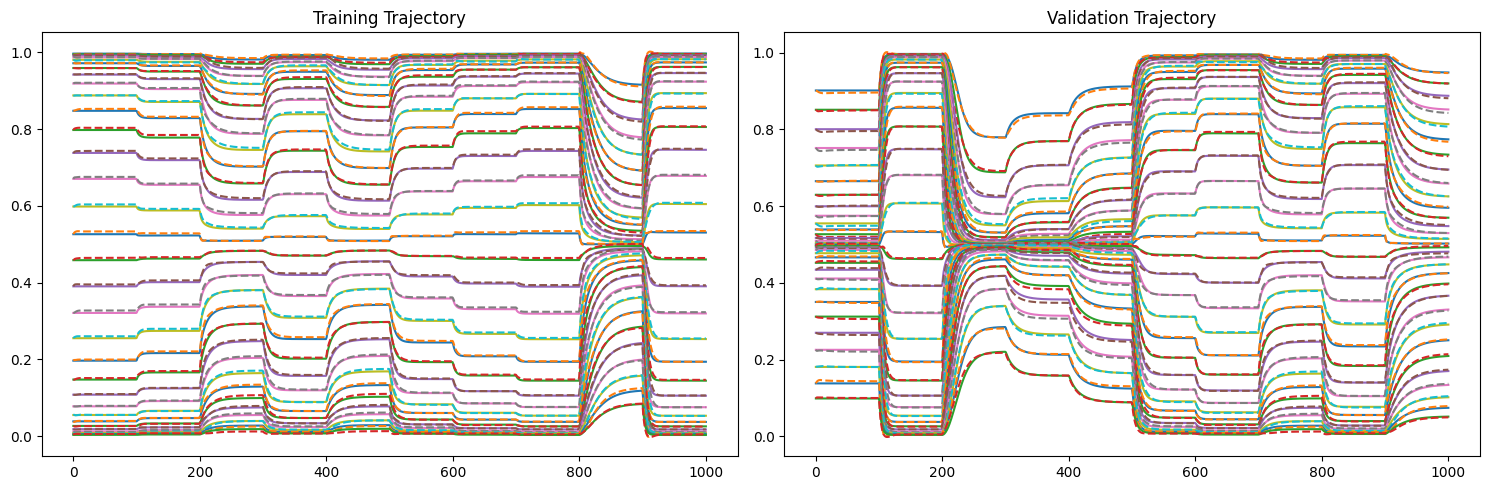

In [37]:
model.eval()
with torch.no_grad():
    pred_train = odeint(nn_dynamics, y_0s, ts, method='rk4', options={'step_size': dt})
    pred_val = odeint(nn_dynamics_val, y_0s_val, ts, method='rk4', options={'step_size': dt})

traj_idx = 0
dims_to_plot = range(32)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for d in dims_to_plot:
    axes[0].plot(ts.cpu(), trajectories[:, traj_idx, d].cpu(), label=f'True dim {d}')
    axes[0].plot(ts.cpu(), pred_train[:, traj_idx, d].cpu(), '--', label=f'Pred dim {d}')
    
axes[0].set_title('Training Trajectory')
#axes[0].legend()

for d in dims_to_plot:
    axes[1].plot(ts.cpu(), trajectories_val[:, traj_idx, d].cpu(), label=f'True dim {d}')
    axes[1].plot(ts.cpu(), pred_val[:, traj_idx, d].cpu(), '--', label=f'Pred dim {d}')
    
axes[1].set_title('Validation Trajectory')
#axes[1].legend()

plt.tight_layout()
plt.show()

In [38]:
torch.save(model.state_dict(), 'model_weights_best.pth')